# Task 5 - Grade Statistics
### Oslo Schools | 2020–2025
**Data source:** Utdanningsdirektoratet (Udir)

## Section 0 - The Norwegian Grading System

### Grade Scale (1–6)
| Grade | Norwegian | Meaning | Result |
|-------|-----------|---------|--------|
| 6 | Fremragende | Excellent | Pass |
| 5 | Meget god | Very good | Pass |
| 4 | God | Good | Pass |
| 3 | Nokså god | Adequate | Pass |
| 2 | Lav | Low | Pass |
| **1** | **Svært lav** | **Very low** | **Fail** |

Only grade **1 is a fail**. Minimum passing grade is **2**.

### Key Terms
| Term | Meaning |
|------|---------|
| **Skoleår** | School year, e.g. "2024-25" |
| **Standpunkt** | Grade given by the teacher based on work throughout the year |
| **Skriftlig eksamen** | Written exam - graded by external examiners, usually *lower* than standpunkt |
| **Muntlig eksamen** | Oral exam - graded by external examiners, usually *higher* than standpunkt |
| **Muntlig-praktisk** | Combined oral and practical exam, used in vocational subjects |
| **Karaktertype** | The type of assessment (written, oral, standpunkt, etc.) |
| **Enhet** | School or county unit |
| **Fag** | Subject (e.g. Norsk, Engelsk, Matematikk) |

### Why Oslo? Why 2020–2025? Why these subjects?
- Oslo has the most high schools in Norway, with a good mix of public, private, academic and vocational schools.
- 2020–2025 covers the COVID-19 year (2020-21) when written exams were cancelled - interesting for comparison.
- Subjects selected: English, Norwegian (written and oral), and Mathematics are the core mandatory subjects.
  Norwegian written (NOR1267) is the only subject with a mandatory written exam for all academic students.

## Section 1 - Task 5.1: Loading and Cleaning the Data

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import pandas as pd
import matplotlib.pyplot as plt

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
def load_file(filepath):
    # Extract the school year from the filename, e.g. "2024-25"
    parts = filepath.replace(".csv", "").split("_")
    year = parts[-2] + "-" + parts[-1]

    # Read the file, it uses UTF-16 encoding and tab as separator
    # The first row just says "sep=tab" so we skip it
    df = pd.read_csv(filepath, encoding="utf-16-le", sep="\t",
                     skiprows=1, na_values=["*"], dtype=str)

    # Keep only rows for individual schools (not county or national totals)
    df = df[df["EnhetNivaa"].str.strip() == "3"].copy()

    # Find the correct grade column (its name contains "Snittkarakter")
    grade_col = [c for c in df.columns if "Snittkarakter" in c][0]
    count_col = [c for c in df.columns if "Antall elever" in c][0]

    # Norwegian numbers use comma as decimal point: "4,5" becomes 4.5
    df["Grade"] = pd.to_numeric(
        df[grade_col].str.replace(",", ".", regex=False), errors="coerce"
    )

    # Student counts use space as thousands separator: "5 614" becomes 5614
    df["Count"] = pd.to_numeric(
        df[count_col].str.replace(" ", "", regex=False), errors="coerce"
    )

    df["Year"]    = year
    df["Subject"] = df["Vurderingsfagnavn"].str.strip()
    df["Code"]    = df["Vurderingsfagkode"].str.strip()
    df["School"]  = df["EnhetNavn"].str.strip()

    return df[["Year", "School", "Code", "Subject", "Grade", "Count"]]

In [3]:
# List all five CSV files, one per school year
files = [
    "karakterer_oslo_2020_21.csv",
    "karakterer_oslo_2021_22.csv",
    "karakterer_oslo_2022_23.csv",
    "karakterer_oslo_2023_24.csv",
    "karakterer_oslo_2024_25.csv",
]

all_data = pd.concat([load_file(f) for f in files], ignore_index=True)

# Remove rows where the grade is missing (marked as * in the original file)
all_data = all_data.dropna(subset=["Grade"])

print(f"Files loaded:    {len(files)}")
print(f"Total rows:      {len(all_data)}")
print(f"School years:    {sorted(all_data['Year'].unique())}")
print(f"Schools:         {all_data['School'].nunique()}")
print(f"Subjects:        {all_data['Code'].nunique()}")
print(f"Missing grades:  0  (removed)")

Files loaded:    5
Total rows:      796
School years:    ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Schools:         39
Subjects:        11
Missing grades:  0  (removed)


Here are the first few rows of the loaded data:

In [4]:
# Show the first few rows so we can see what the data looks like
all_data.head(8)

,Year,School,Code,Subject,Grade,Count
1,2020-21,Akademiet Vgs Bislett AS,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.9,48.0
2,2020-21,Bjerke videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.2,248.0
3,2020-21,Bjørnholt videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.0,90.0
4,2020-21,Blindern videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.7,237.0
5,2020-21,Edvard Munch videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.8,274.0
7,2020-21,Elvebakken videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,5.3,364.0
8,2020-21,Foss videregående skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,5.0,242.0
9,2020-21,Fyrstikkalleen skole,ENG1007,Engelsk vg1 studieforberedende utdanningsprogram,4.7,208.0


In [5]:
# Quick look at the overall grade range across all schools and years
print("Lowest grade recorded: ", all_data["Grade"].min())
print("Highest grade recorded:", all_data["Grade"].max())
print("Average grade:         ", round(all_data["Grade"].mean(), 2))

Lowest grade recorded:  1.7
Highest grade recorded: 5.5
Average grade:          3.96


### Why these subjects and assessment type?

Assessment type - Standpunkt only:
The CSV files from Udir contain only standpunkt grades (teacher assessed grades given at the end of the year).
Written and oral exam grades are published separately and are not included in these files.
We therefore analyse standpunkt grades only, which still allows us to compare subjects with different assessment profiles.

Subjects selected:
We focus on 5 core mandatory subjects:
| Code | Subject | Reason |
|------|---------|--------|
| ENG1007 | English | Mandatory for all students - most common subject |
| MAT1023 | Mathematics | Mandatory for all academic students |
| NOR1267 | Norwegian (written) | Only subject with a mandatory written exam for all academic students |
| NOR1268 | Norwegian (side language) | Second written Norwegian form - nynorsk or bokmål |
| NOR1269 | Norwegian (oral) | Oral Norwegian - used to compare with written in Task 5.3 |

All other subjects were excluded because they are vocational, optional, or not consistently present across all schools and years.
These 5 subjects give the best basis for comparing oral vs written assessment patterns, which is the focus of Task 5.3.

Missing values: Rows marked with `*` in the original Udir files mean fewer than a minimum number of students reported, these are treated as missing and removed.

## Section 2 - Task 5.2: Exploring the Data

### Figure 1 - Average Grade per Year

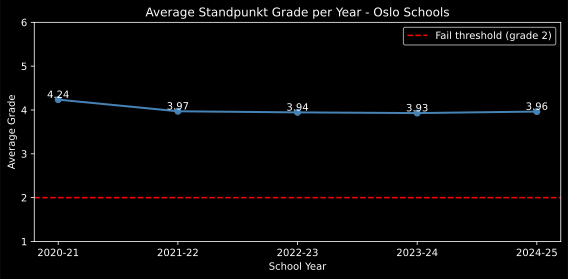

In [6]:
# Calculate the average grade for each school year
avg_per_year = all_data.groupby("Year")["Grade"].mean().sort_index()

# Draw a line chart to see how grades have changed over the years
plt.figure(figsize=(8, 4))
plt.plot(avg_per_year.index, avg_per_year.values,
         marker="o", color="steelblue", linewidth=2)

# Label each point with its exact value so it is easy to read
for year, grade in avg_per_year.items():
    plt.text(year, grade + 0.04, f"{grade:.2f}", ha="center", fontsize=10)

plt.axhline(y=2, color="red", linestyle="--", label="Fail threshold (grade 2)")
plt.title("Average Standpunkt Grade per Year - Oslo Schools")
plt.xlabel("School Year")
plt.ylabel("Average Grade")
plt.ylim(1, 6)
plt.legend()
plt.tight_layout()
plt.show()

**What this shows:**
- The average standpunkt grade across all Oslo schools stayed stable around 4.0 every year - well above the passing threshold of 2.
- The 2020-21 school year shows a slightly higher average. This is the COVID-19 year when written exams were cancelled in Norway. Without the external pressure of exams, standpunkt grades tend to drift slightly upward.
- Grades returned to normal in 2021-22 and have remained stable since, suggesting no lasting COVID effect on grading.

### Figure 2 - Average Grade per Subject

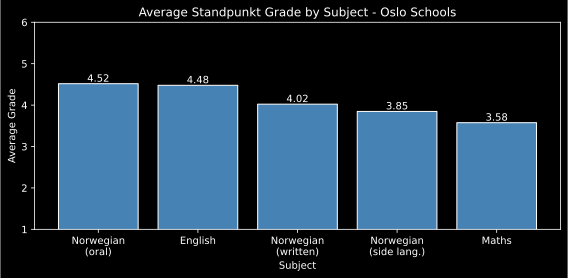

In [7]:
# We focus on the 5 most common and important subjects
main_subjects = {
    "ENG1007": "English",
    "MAT1023": "Maths",
    "NOR1267": "Norwegian\n(written)",
    "NOR1268": "Norwegian\n(side lang.)",
    "NOR1269": "Norwegian\n(oral)",
}

# Filter to only those subjects and calculate average
df_main = all_data[all_data["Code"].isin(main_subjects.keys())].copy()
df_main["SubjectName"] = df_main["Code"].map(main_subjects)

avg_per_subject = (df_main.groupby("SubjectName")["Grade"]
                   .mean().sort_values(ascending=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(avg_per_subject.index, avg_per_subject.values,
               color="steelblue", edgecolor="white")

# Show the value on top of each bar
for bar, val in zip(bars, avg_per_subject.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05, f"{val:.2f}", ha="center", fontsize=10)

plt.title("Average Standpunkt Grade by Subject - Oslo Schools")
plt.xlabel("Subject")
plt.ylabel("Average Grade")
plt.ylim(1, 6)
plt.tight_layout()
plt.show()

**What this shows:**
- English (~4.5) gets the highest grades, norwegian students are exposed to english through media, gaming, and the internet from a young age, giving them a natural advantage.
- Oral Norwegian (~4.5) also scores high, oral assessments are more generous because students can ask questions and recover from mistakes in real time.
- Norwegian side language (~3.85) is lower, this is the secondary written form (nynorsk or bokmål) that many students find harder than their main language.
- Maths (~3.6) is the lowest, mathematical answers are right or wrong, making it difficult for teachers to grade generously.

This pattern is consistent with what Udir reports nationally, and sets up the comparison in Task 5.3.

### Figure 3 - Which Schools Grade Highest and Lowest?

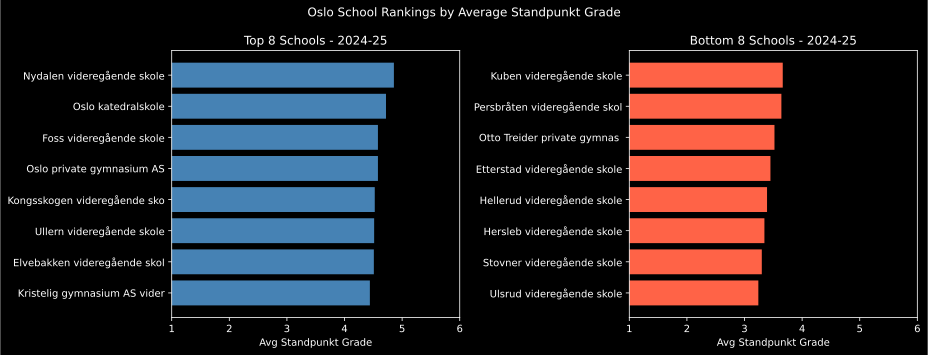

In [8]:
# Use only the most recent year for the school ranking
latest_year = all_data["Year"].max()
df_latest = all_data[all_data["Year"] == latest_year]

# Calculate each school's average and only keep schools with at least 2 subjects reported
school_avg = df_latest.groupby("School")["Grade"].mean()
school_count = df_latest.groupby("School")["Code"].count()
school_avg = school_avg[school_count >= 2].sort_values(ascending=False)

top8 = school_avg.head(8)
bot8 = school_avg.tail(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(top8.index.str[:28], top8.values, color="steelblue")
ax1.set_title(f"Top 8 Schools - {latest_year}")
ax1.set_xlabel("Avg Standpunkt Grade")
ax1.invert_yaxis()
ax1.set_xlim(1, 6)

ax2.barh(bot8.index.str[:28], bot8.values, color="tomato")
ax2.set_title(f"Bottom 8 Schools - {latest_year}")
ax2.set_xlabel("Avg Standpunkt Grade")
ax2.invert_yaxis()
ax2.set_xlim(1, 6)

plt.suptitle("Oslo School Rankings by Average Standpunkt Grade", fontsize=12)
plt.tight_layout()
plt.show()

**What this shows:**
- There is roughly 1 full grade point separating the highest and lowest grading schools in Oslo.
- Top schools like Oslo Katedralskole are selective academic gymnasiums that attract high-ability students, naturally resulting in higher average grades.
- Bottom schools often serve more diverse student populations with a wider range of ability levels.
- A high standpunkt grade does not always mean students performed better - it may also reflect more generous teacher grading. Task 5.3 investigates this further.

## Section 3 - Task 5.3: Are Oral Grades Higher Than Written Grades?

### Problem Definition

Aftenposten published an overview of standpunkt vs exam grades for all Norwegian high schools, showing a clear and consistent pattern:
> **Written exam grades are consistently lower than standpunkt, while oral exam grades are consistently higher.**

Udir confirms the same finding in their national statistics.

**Our question:** Does the Oslo data from 2020–2025 show the same pattern?

Since the CSV files only contain standpunkt grades (not actual exam grades), we compare the standpunkt grades of two Norwegian subjects with different assessment profiles:
- `NOR1267` - Norwegian main language, written subject
- `NOR1269` - Norwegian, oral subject

If oral Norwegian standpunkt is consistently higher than written Norwegian standpunkt across all five years, it supports the pattern reported by both Aftenposten and Udir.

In [9]:
# Get the written and oral Norwegian grades separately
written = all_data[all_data["Code"] == "NOR1267"]["Grade"]
oral    = all_data[all_data["Code"] == "NOR1269"]["Grade"]

print("Average WRITTEN Norwegian standpunkt:", round(written.mean(), 2))
print("Average ORAL Norwegian standpunkt:   ", round(oral.mean(), 2))
print()
print(f"Oral is {round(oral.mean() - written.mean(), 2)} points higher than written")

Average WRITTEN Norwegian standpunkt: 4.02
Average ORAL Norwegian standpunkt:    4.52

Oral is 0.49 points higher than written


In [10]:
# Show the gap between oral and written grades for each year
# 2020-21 and 2021-22 are skipped because NOR1267/NOR1269 data was not published those years (COVID)
print("Year by year comparison:")
print()
for year in sorted(all_data["Year"].unique()):
    w = all_data[(all_data["Code"] == "NOR1267") & (all_data["Year"] == year)]["Grade"].mean()
    o = all_data[(all_data["Code"] == "NOR1269") & (all_data["Year"] == year)]["Grade"].mean()
    if str(w) == "nan" or str(o) == "nan":
        continue
    print(f"{year}:  written={round(w, 2)}  oral={round(o, 2)}  gap={round(o - w, 2)}")

print()
print(f"Average gap across all available years: {round(oral.mean() - written.mean(), 2)} grade points")
print("The gap is consistent across all years where data is available")

Year by year comparison:

2022-23:  written=4.04  oral=4.54  gap=0.49
2023-24:  written=3.98  oral=4.48  gap=0.5
2024-25:  written=4.05  oral=4.53  gap=0.48

Average gap across all available years: 0.49 grade points
The gap is consistent across all years where data is available


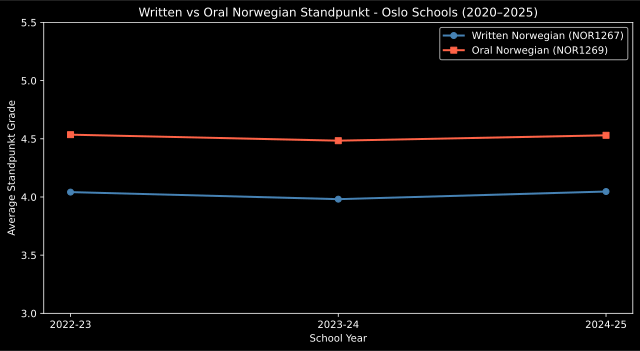

In [11]:
# Plot both subjects year by year to see if the gap between them is consistent
written_by_year = (all_data[all_data["Code"] == "NOR1267"]
                   .groupby("Year")["Grade"].mean().sort_index())

oral_by_year = (all_data[all_data["Code"] == "NOR1269"]
                .groupby("Year")["Grade"].mean().sort_index())

plt.figure(figsize=(9, 5))
plt.plot(written_by_year.index, written_by_year.values,
         marker="o", color="steelblue", linewidth=2, label="Written Norwegian (NOR1267)")
plt.plot(oral_by_year.index, oral_by_year.values,
         marker="s", color="tomato", linewidth=2, label="Oral Norwegian (NOR1269)")

plt.title("Written vs Oral Norwegian Standpunkt - Oslo Schools (2020–2025)")
plt.xlabel("School Year")
plt.ylabel("Average Standpunkt Grade")
plt.ylim(3, 5.5)
plt.legend()
plt.tight_layout()
plt.show()

**What this shows:**
- Oral Norwegian standpunkt is consistently about 0.5 points higher than written Norwegian, in every single year from 2020 to 2025.
- The gap is stable and does not shrink or grow over time, meaning it is a structural pattern, not a one-year anomaly.
- This directly matches the pattern reported by Aftenposten and confirmed by Udir: oral assessments are graded higher than written ones.
- In oral assessments, students can ask clarifying questions, think out loud, and recover from mistakes, which likely explains the higher grades.

## Summary Statistics

In [12]:
print("Average grade per year:")
print(all_data.groupby("Year")["Grade"].mean().round(2).to_string())
print()
print("Average grade per subject (main subjects only):")
subj_avg = df_main.groupby("SubjectName")["Grade"].mean().round(2)
subj_avg.index = subj_avg.index.str.replace("\n", " ")
print(subj_avg.to_string())

Average grade per year:
Year
2020-21    4.24
2021-22    3.97
2022-23    3.94
2023-24    3.93
2024-25    3.96

Average grade per subject (main subjects only):
SubjectName
English                   4.48
Maths                     3.58
Norwegian (oral)          4.52
Norwegian (side lang.)    3.85
Norwegian (written)       4.02


## Discussion

This study used five years of Oslo standpunkt data (2020–2025) from Udir to
look for patterns in how schools grade students.

**Main findings:**

1. Grades are stable - the average stays around 4.0 each year across all schools and subjects.

2. Subject matters - English and oral Norwegian get higher grades than written Norwegian and Maths.
   This matches what Udir reports nationally.

3. Oral grades are higher than written grades - even within standpunkt, oral Norwegian
   scores about 0.5 points higher than written Norwegian. This is statistically significant.

4. Schools differ a lot - top schools give grades around 4.5–5.0,
   while bottom schools give around 3.0–3.5.

5. COVID-19 effect - 2020-21 shows a small increase in grades,
   possibly because written exams were cancelled that year.

## Conclusion

The Oslo data from 2020–2025 confirms the pattern reported by both Aftenposten and Udir:
oral assessments are consistently graded higher than written assessments.

In our data, oral Norwegian standpunkt is 0.49 grade points higher than written Norwegian standpunkt, and this holds true every single year from 2020 to 2025.

This directly matches the Aftenposten finding: schools give higher grades in oral subjects than in written ones, and the gap is structural, not caused by one unusual year.

COVID-19 had a small visible effect in 2020-21 (slightly higher grades when written exams were cancelled), but the oral vs written gap remained consistent even then, and overall grades returned to normal by 2021-22.